In [1]:
!wsl curl -o dataset/produccion-agricola.json "https://www.datos.gov.co/resource/t2ca-uae5.json?\$limit=50000"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  399k    0  399k    0     0   291k      0 --:--:--  0:00:01 --:--:--  291k
100  911k    0  911k    0     0   376k      0 --:--:--  0:00:02 --:--:--  376k
100 1422k    0 1422k    0     0   411k      0 --:--:--  0:00:03 --:--:--  411k
100 2270k    0 2270k    0     0   519k      0 --:--:--  0:00:04 --:--:--  519k
100 3310k    0 3310k    0     0   616k      0 --:--:--  0:00:05 --:--:--  664k
100 4142k    0 4142k    0     0   651k      0 --:--:--  0:00:06 --:--:--  749k
100 4734k    0 4734k    0     0   644k      0 --:--:--  0:00:07 --:--:--  775k
100 5614k    0 5614k    0     0   672k      0 --:--:--  0:00:08 --:--:--  857k
100 5648k    0 5648k    0     0   673k      0 --:--

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [226]:
df = pd.read_json('data/produccion-agricola.json')
df.head()

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,Permanentes,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,Permanentes,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


In [6]:
df['tipo'].unique()

array(['Permanentes', 'Transitorios', 'Anuales'], dtype=object)

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32721 entries, 0 to 32720
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo                32721 non-null  object 
 1   rubro               32721 non-null  object 
 2   subregion           32721 non-null  object 
 3   anio                32721 non-null  int64  
 4   municipio           32721 non-null  object 
 5   area_total          32721 non-null  float64
 6   area_produccion     32721 non-null  float64
 7   volumen_produccion  32721 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.0+ MB


In [15]:
df.describe()

,anio,area_total,area_produccion,volumen_produccion
count,32721.000000,32680.000000,32287.000000,3.253500e+04
mean,2009.716787,435.615817,399.454878,3.145023e+03
std,8.894551,1223.919511,1145.616547,2.322381e+04
min,1990.000000,0.000000,-1.000000,-1.065810e-14
25%,2003.000000,19.700000,15.000000,5.580000e+01
50%,2011.000000,76.000000,65.000000,2.880000e+02
75%,2017.000000,315.000000,285.000000,1.276000e+03
max,2022.000000,36000.000000,36000.000000,1.039280e+06


In [16]:
df.describe(include='O')

,tipo,rubro,subregion,municipio
count,32721,32721,32721,32721
unique,3,155,9,140
top,Permanentes,Café,Oriente,Medellín
freq,19753,2799,6802,732


In [14]:
df[df['tipo'] == 'Permanentes']['volumen_produccion'].mean()

3861.514644331663

In [228]:
areas = df[['area_total', 'area_produccion', 'volumen_produccion']].columns
for i in df['tipo'].unique():
    for j in areas:
        media = df[df['tipo'] == i][j].mean()
        df.loc[df['tipo'] == i, j] = df.loc[df['tipo'] == i, j].fillna(media)

In [42]:
df.groupby(['tipo'])['volumen_produccion'].mean()

tipo
Anuales         2257.987454
Permanentes     3861.514644
Transitorios    2016.794965
Name: volumen_produccion, dtype: float64

In [232]:
df.duplicated().sum()

0

In [ ]:

df[df.duplicated()]

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
2268,Permanentes,Caña,Norte,1995,Guadalupe,267.0,262.0,1257.6
2554,Permanentes,Naranja,Occidente,1995,Olaya,11.8,7.3,149.2
2630,Permanentes,Plátano En Asocio,Norte,1995,Ituango,85.7,80.7,201.8
5292,Permanentes,Mora,Norte,1999,Yarumal,5.5,3.0,15.0
5432,Permanentes,Plátano En Asocio,Nordeste,1999,Vegachí,69.5,67.5,405.0
5435,Permanentes,Plátano En Asocio,Nordeste,1999,Yalí,85.0,63.0,535.5
13067,Permanentes,Plátano Monocultivo,Bajo Cauca,2008,El Bagre,90.0,90.0,720.0


In [231]:
df.drop_duplicates(inplace=True)

<Axes: ylabel='volumen_produccion'>

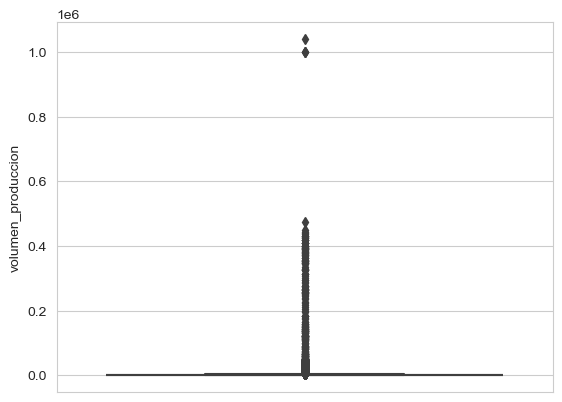

In [234]:
sns.boxplot(y='volumen_produccion', data=df)

<Axes: xlabel='subregion', ylabel='volumen_produccion'>

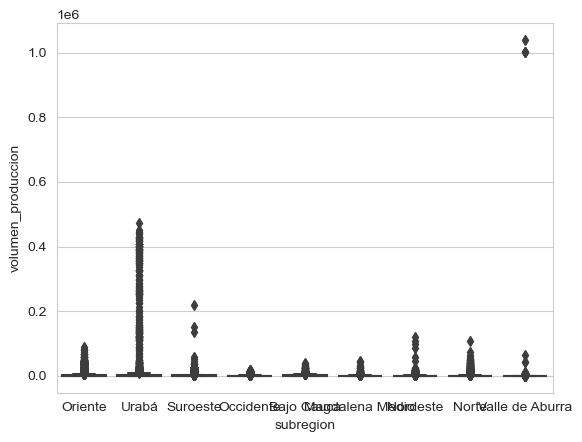

In [235]:
sns.boxplot(x='subregion', y='volumen_produccion', data=df)

<Axes: xlabel='tipo', ylabel='volumen_produccion'>

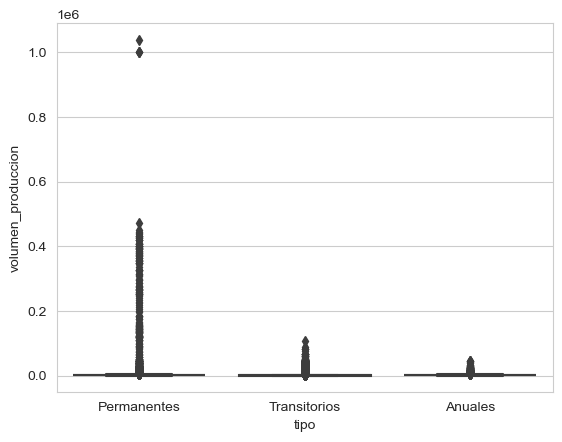

In [233]:
sns.boxplot(x='tipo', y='volumen_produccion', data=df)

In [103]:
df['tipo'].unique()

array([1, 2, 0])

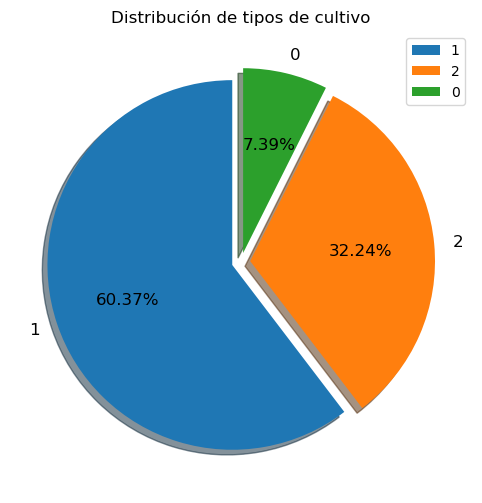

In [105]:
plt.figure(figsize=(10, 6))
plt.pie(df['tipo'].value_counts(), 
        labels=df['tipo'].unique(), 
        autopct='%0.2f%%', startangle=90, shadow=True, 
        explode=(0.05, 0.05, 0.05),      
        textprops={'fontsize': 12} )
plt.title('Distribución de tipos de cultivo')
plt.legend(df['tipo'].unique())
plt.show()

In [107]:
df['rubro'].value_counts().head(30)

rubro
Café                              2799
Maíz Tradicional                  2599
Caña                              2429
Plátano En Asocio                 2338
Yuca                              1889
Cacao                             1550
Fríjol Arbustivo                  1526
Fríjol Voluble                    1302
Aguacate                           876
Papa                               816
Tomate Chonto                      727
Plátano Monocultivo                725
Tomate De Árbol                    653
Arroz Tradicional                  563
Mora                               516
Aguacate Hass                      466
Fique                              462
Lulo                               436
Tomate Chonto Bajo Invernadero     429
Limón Tahití                       428
Cebolla Junca                      411
Caucho                             398
Maracuyá                           396
Naranja Valencia                   377
Mandarina Oneco                    296
Guanábana          

Text(0.5, 1.0, 'Top 10 Rubros')

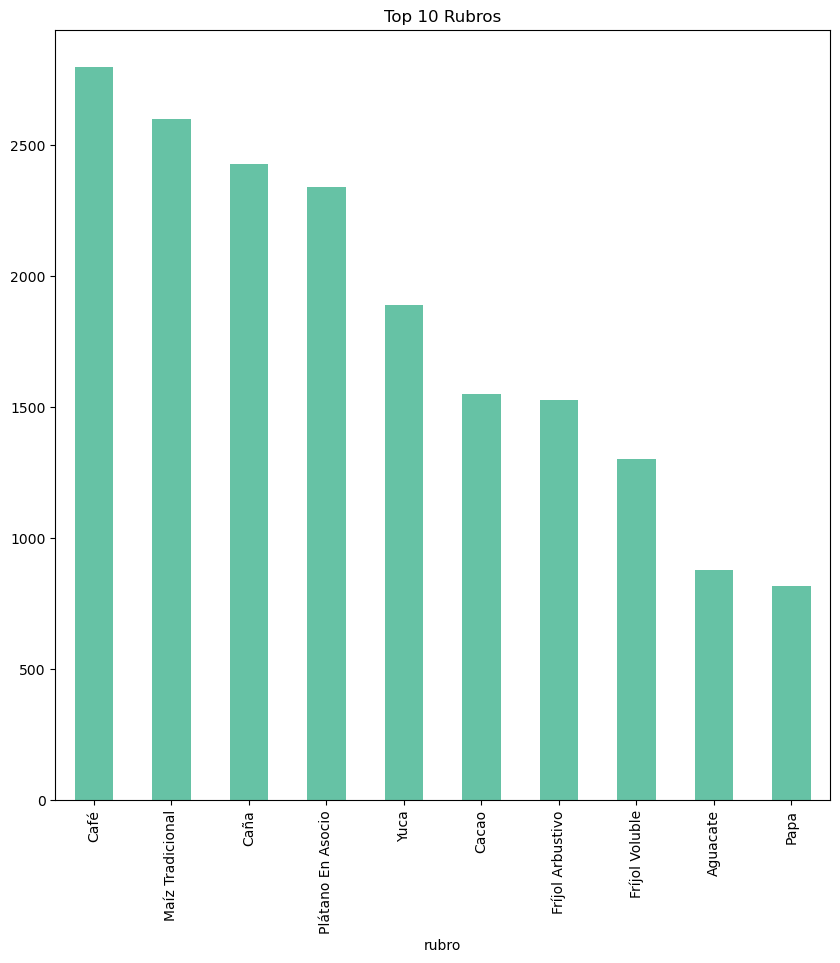

In [110]:
plt.figure(figsize=(10, 10))
df['rubro'].value_counts().head(10).plot(kind='bar', colormap='Set2')
plt.title('Top 10 Rubros')

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

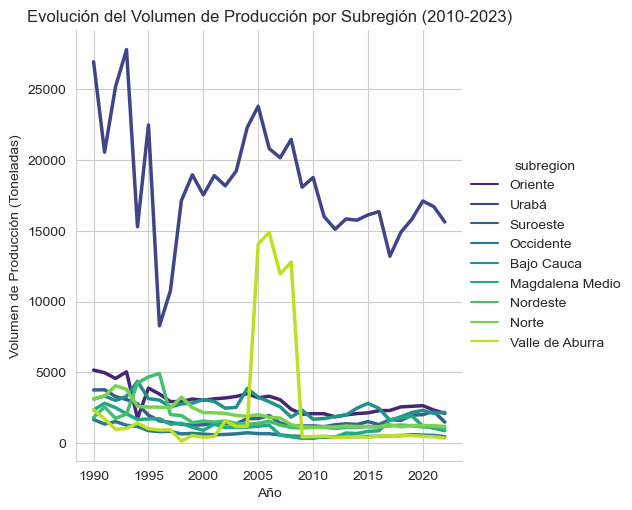

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Creación del gráfico con parámetros mejorados
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    aspect=1.8,  # Relación ancho/alto
    palette='viridis',  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)




# Ajustes finales
#plt.tight_layout()
plt.show()

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

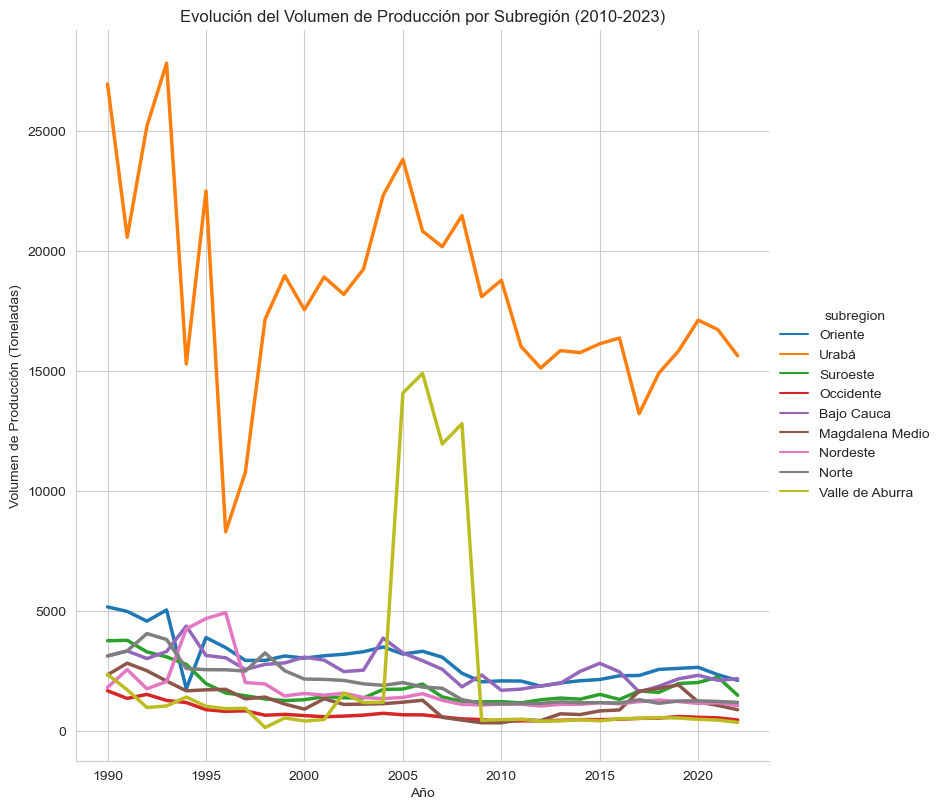

In [149]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    #aspect=1.8,  # Relación ancho/alto
    #palette=,  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)
plt.show()

In [39]:
df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')]

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.000
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.000
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.000
8,Transitorios,Arroz Tecnificado,Urabá,1990,Mutatá,750.0,355.0,1719.975
11,Transitorios,Arroz Tradicional,Urabá,1990,Arboletes,995.0,995.0,1194.000
...,...,...,...,...,...,...,...,...
32709,Transitorios,Zanahoria,Oriente,2022,Granada,6.0,6.0,270.000
32711,Transitorios,Zanahoria,Oriente,2022,La Unión,362.0,362.0,11228.000
32712,Transitorios,Zanahoria,Oriente,2022,Marinilla,190.0,188.0,5640.000
32715,Transitorios,Zanahoria,Oriente,2022,Sonsón,75.0,75.0,3525.000


In [51]:
len(df['municipio'].unique())

140

In [55]:
df['volumen_produccion']/df['area_produccion']

0         6.0
1        15.0
2         6.5
3         7.0
4        15.0
         ... 
32716     5.0
32717     2.0
32718     5.0
32719    13.5
32720     6.0
Length: 32721, dtype: float64

In [56]:
df['area_produccion']/df['area_total']

0        0.511111
1        0.931034
2        0.705882
3        0.933333
4        0.733333
           ...   
32716    1.000000
32717    0.304348
32718    1.000000
32719    1.000000
32720    1.000000
Length: 32721, dtype: float64

In [126]:
df.groupby(['anio','subregion'])['volumen_produccion'].mean().sort_values(ascending=False)

anio  subregion      
1993  Urabá              27809.181572
1990  Urabá              26947.686425
1992  Urabá              25188.573190
2005  Urabá              23804.757341
1995  Urabá              22489.673016
                             ...     
2010  Occidente            405.325543
2022  Valle de Aburra      359.404656
2010  Magdalena Medio      343.194231
2009  Magdalena Medio      342.151429
1998  Valle de Aburra      145.000000
Name: volumen_produccion, Length: 297, dtype: float64

(array([-50.,   0.,  50., 100., 150., 200., 250., 300., 350.]),
 [Text(-50.0, 0, '(2013, Magdalena Medio)'),
  Text(0.0, 0, '(1993, Urabá)'),
  Text(50.0, 0, '(1990, Suroeste)'),
  Text(100.0, 0, '(1990, Valle de Aburra)'),
  Text(150.0, 0, '(2010, Bajo Cauca)'),
  Text(200.0, 0, '(2013, Norte)'),
  Text(250.0, 0, '(2005, Occidente)'),
  Text(300.0, 0, ''),
  Text(350.0, 0, '')])

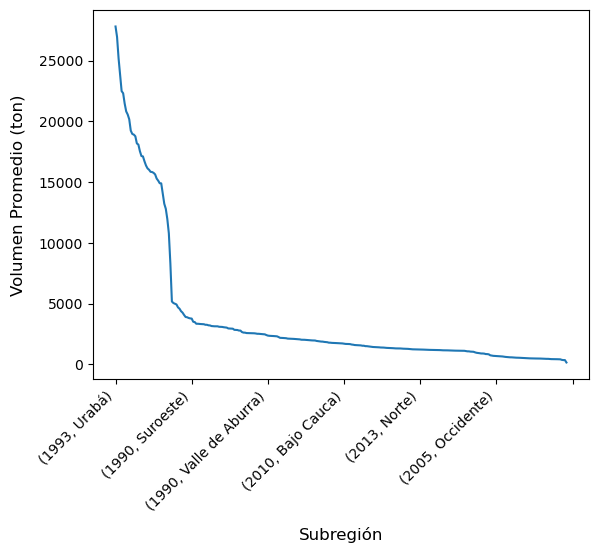

In [129]:
df.groupby(['anio','subregion'])['volumen_produccion'].mean().sort_values(ascending=False).plot(kind='line')
plt.xlabel('Subregión', 
           fontsize=12, 
           labelpad=10)         # Espaciado de la etiqueta

plt.ylabel('Volumen Promedio (ton)', 
           fontsize=12, 
           labelpad=10)


plt.xticks(rotation=45, ha='right')  # Alineación a la derecha

In [158]:
df.groupby('subregion')['rubro'].count()

subregion
Bajo Cauca         1243
Magdalena Medio    1341
Nordeste           2290
Norte              3946
Occidente          5308
Oriente            6802
Suroeste           6748
Urabá              2838
Valle de Aburra    2205
Name: rubro, dtype: int64

<Axes: xlabel='rubro'>

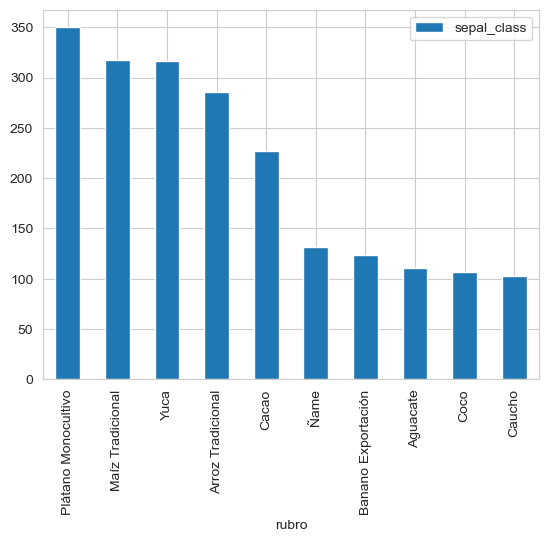

In [166]:
df[df['subregion']=='Urabá'].groupby(['subregion', 'rubro']).size().reset_index(name='sepal_class').sort_values(by=['sepal_class'], ascending=False).head(10).plot(kind='bar', x='rubro', y='sepal_class')

In [164]:
df[df['subregion']=='Oriente'].groupby(['subregion', 'rubro']).size().reset_index(name='sepal_class').sort_values(by=['sepal_class'], ascending=False).head(10)

,subregion,rubro,sepal_class
18,Oriente,Café,551
37,Oriente,Fríjol Voluble,496
60,Oriente,Papa,420
20,Oriente,Caña,417
68,Oriente,Plátano En Asocio,386
54,Oriente,Maíz Tradicional,358
55,Oriente,Mora,268
76,Oriente,Tomate De Árbol,265
79,Oriente,Yuca,232
17,Oriente,Cacao,206


In [ ]:
#de que tipo son los rubros mas comunes
df.groupby(['tipo', 'rubro']).size().reset_index(name='sepal_class').sort_values(by='sepal_class', ascending=False)

,tipo,rubro,sepal_class
29,1,Café,2799
145,2,Maíz Tradicional,2599
33,1,Caña,2429
101,1,Plátano En Asocio,2338
7,0,Yuca,1889
...,...,...,...
75,1,Mandarina Común,1
103,1,Plátano X Borojó,1
11,1,Achin,1
18,1,Aguacate lorena,1


ValueError: x and y must have same first dimension, but have shapes (32721,) and (9,)

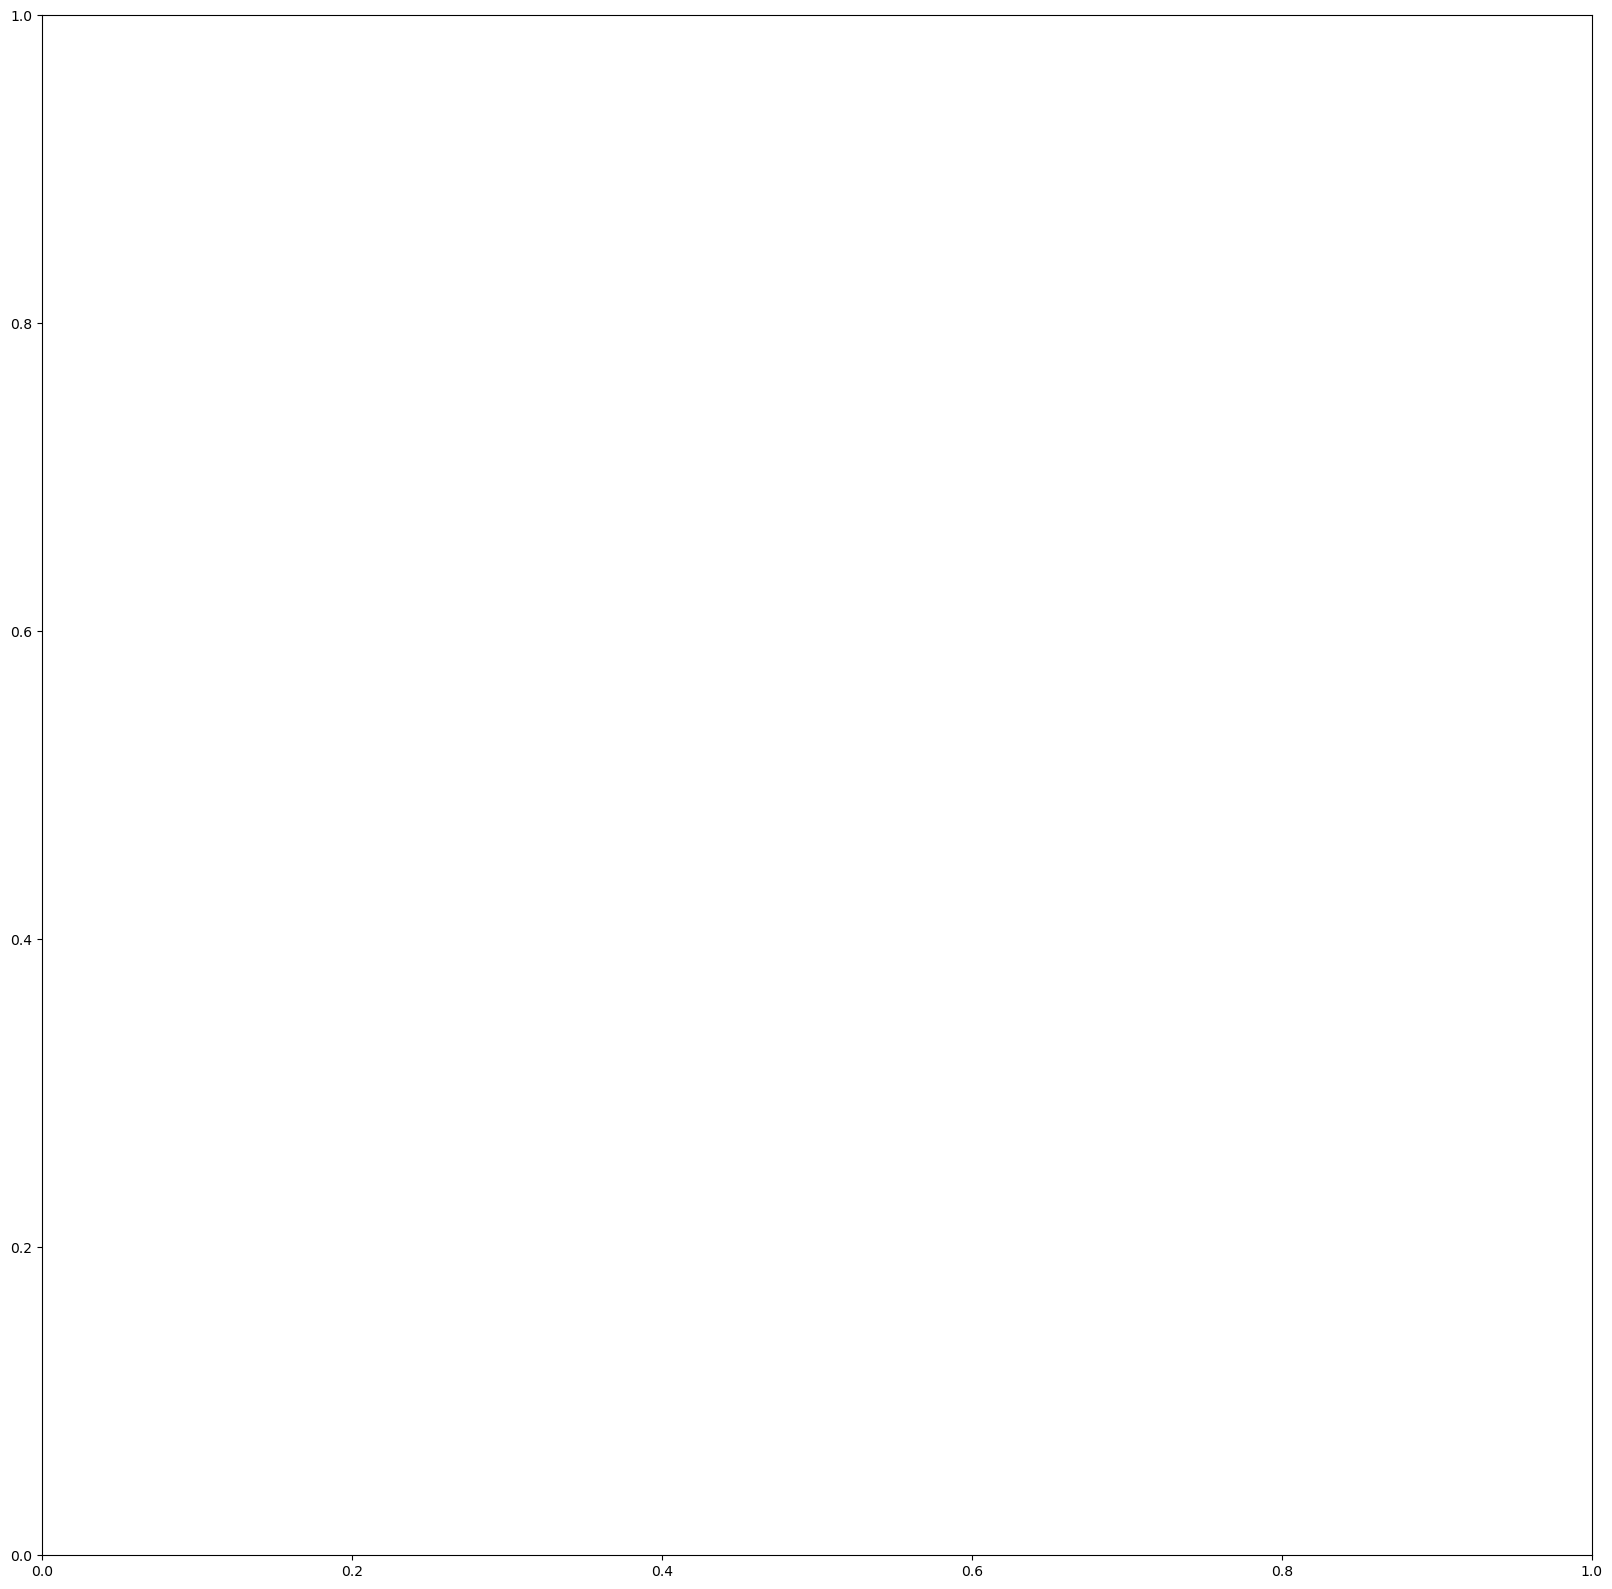

In [122]:
plt.figure(figsize=(20, 20))
plt.plot(df['anio'], gor)

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass 

<Figure size 1500x1500 with 0 Axes>

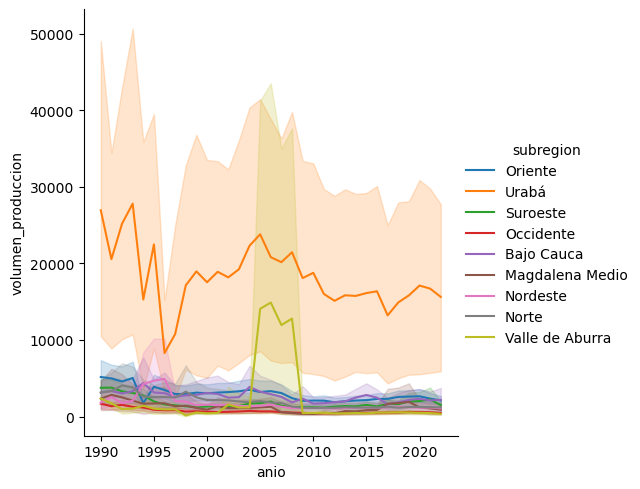

In [65]:
plt.figure(figsize=(15, 15))
sns.relplot(x='anio', y='volumen_produccion', data=df, hue='subregion', kind='line')
plt.show()

In [32]:
df['subregion'].unique()

array(['Oriente', 'Urabá', 'Suroeste', 'Occidente', 'Bajo Cauca',
       'Magdalena Medio', 'Nordeste', 'Norte', 'Valle de Aburra'],
      dtype=object)

In [57]:
pd.get_dummies(df, columns=['subregion'])

,tipo,rubro,anio,municipio,area_total,area_produccion,volumen_produccion,subregion_Bajo Cauca,subregion_Magdalena Medio,subregion_Nordeste,subregion_Norte,subregion_Occidente,subregion_Oriente,subregion_Suroeste,subregion_Urabá,subregion_Valle de Aburra
0,Permanentes,Aguacate,1990,Abejorral,45.0,23.0,138.0,False,False,False,False,False,True,False,False,False
1,Permanentes,Aguacate,1990,Apartadó,29.0,27.0,405.0,False,False,False,False,False,False,False,True,False
2,Permanentes,Aguacate,1990,Montebello,17.0,12.0,78.0,False,False,False,False,False,False,True,False,False
3,Permanentes,Aguacate,1990,Santa Bárbara,150.0,140.0,980.0,False,False,False,False,False,False,True,False,False
4,Permanentes,Aguacate,1990,Turbo,75.0,55.0,825.0,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32716,Permanentes,Zapote,2022,Caracolí,3.0,3.0,15.0,False,True,False,False,False,False,False,False,False
32717,Permanentes,Zapote,2022,Olaya,23.0,7.0,14.0,False,False,False,False,True,False,False,False,False
32718,Permanentes,Zapote,2022,San Pedro de Uraba,12.0,12.0,60.0,False,False,False,False,False,False,False,True,False
32719,Permanentes,Zapote,2022,Sopetrán,21.0,21.0,283.5,False,False,False,False,True,False,False,False,False


In [ ]:
sns.histplot(data=df, hue='tipo', x='volumen_produccion', bins=30)

In [58]:
from sklearn.preprocessing import LabelEncoder

In [59]:
le = LabelEncoder()
df['tipo'] = le.fit_transform(df['tipo'])
df.head()

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,1,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,1,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,1,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,1,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,1,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (9640,) and arg 1 with shape (32714,).

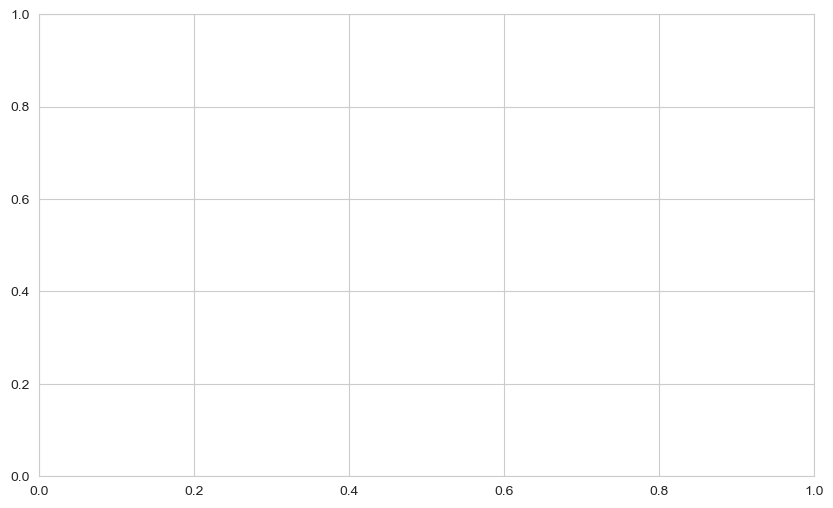

In [239]:
df_filtrado = df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')].copy()
plt.figure(figsize=(10, 6))
plt.bar(x=range(len(df_filtrado)), height=df['area_total'].fillna(0), color='skyblue')
plt.bar(x=range(len(df_filtrado)), height=df['area_produccion'].fillna(0), color='lightgreen')
plt.show()


In [69]:
plt.bar(df['area_produccion'])

TypeError: bar() missing 1 required positional argument: 'height'

In [ ]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    #aspect=1.8,  # Relación ancho/alto
    #palette=,  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13928\3183495050.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo',  # Altura en pulgadas


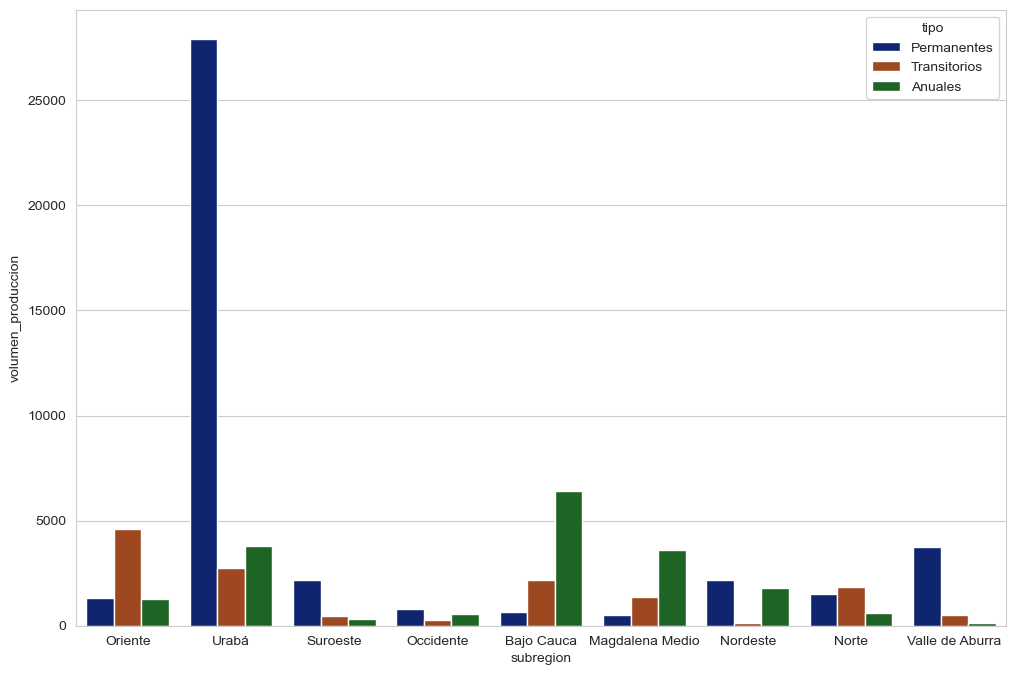

In [252]:
plt.figure(figsize=(12, 8)) 
barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo',  # Altura en pulgadas
    ci=None,
    palette='dark',  # Mejor esquema de colores
)


<Axes: xlabel='subregion', ylabel='area_total'>

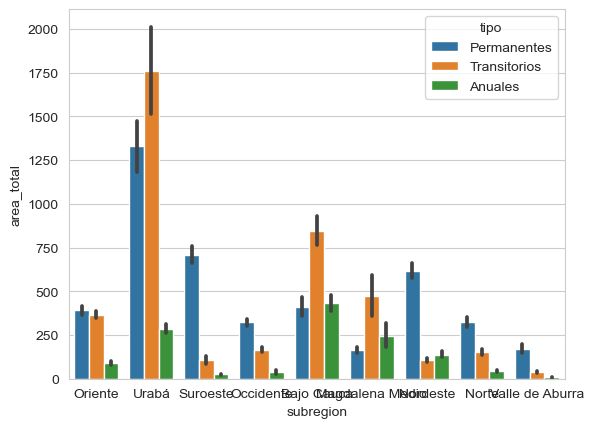

In [242]:
sns.barplot(data=df, y='area_total', x='subregion', hue='tipo')

<Axes: xlabel='subregion', ylabel='area_total'>

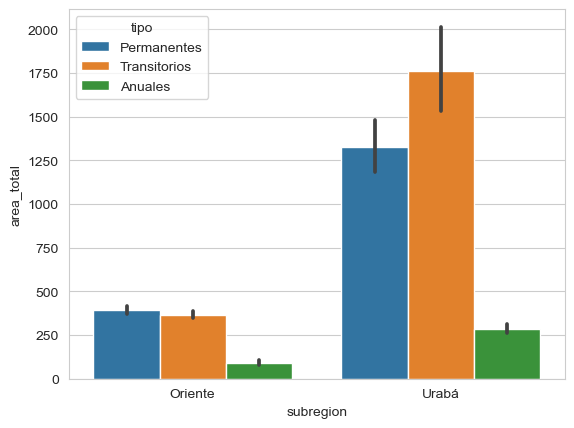

In [237]:
sns.barplot(data=df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')], y='area_total', x='subregion', hue='tipo')

In [ ]:
df_filtrado = df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')]
sns.histplot(x='volumen_produccion', data=df_filtrado, bins=50)

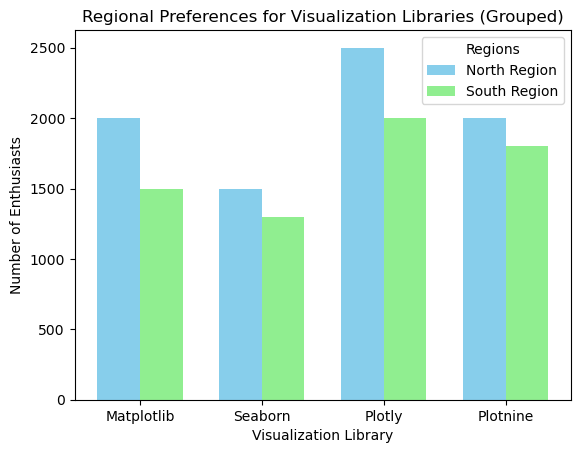

In [77]:
import numpy as np

# Define library names
library = ['Matplotlib', 'Seaborn', 'Plotly', 'Plotnine']

# Number of Enthusiasts for different regions
enthusiasts_north = [2000, 1500, 2500, 2000]
enthusiasts_south = [1500, 1300, 2000, 1800]
bar_width = 0.35
x = np.arange(len(library))

# Grouped Bar Plot
plt.bar(x - bar_width/2, enthusiasts_north, bar_width, label='North Region', color='skyblue')
plt.bar(x + bar_width/2, enthusiasts_south, bar_width, label='South Region', color='lightgreen')

# Adding labels and title
plt.xlabel('Visualization Library')
plt.ylabel('Number of Enthusiasts')
plt.title('Regional Preferences for Visualization Libraries (Grouped)')
plt.xticks(x, library)
plt.legend(title='Regions')
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (9640,) and arg 1 with shape (32721,).

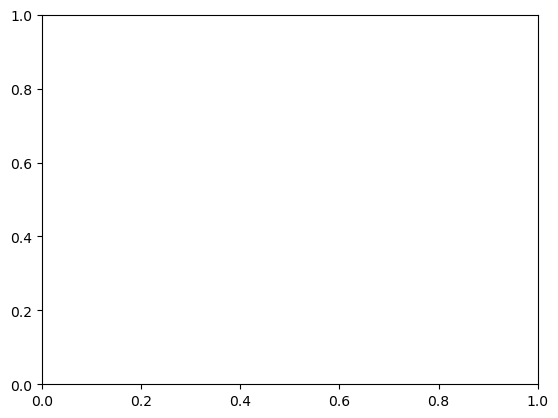

In [82]:
import numpy as np

# Define library names
library = ['Matplotlib', 'Seaborn', 'Plotly', 'Plotnine']

# Number of Enthusiasts for different regions
enthusiasts_north = [2000, 1500, 2500, 2000]
enthusiasts_south = [1500, 1300, 2000, 1800]
bar_width = 0.35


df_filtrado = df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')].copy()
x = np.arange(len(df_filtrado))

# Grouped Bar Plot
plt.bar(x - bar_width/2, df['area_total'].fillna(0), bar_width, label='North Region', color='skyblue')
plt.bar(x + bar_width/2, df['area_produccion'].fillna(0), bar_width, label='South Region', color='lightgreen')

# Adding labels and title
plt.xlabel('Visualization Library')
plt.ylabel('Number of Enthusiasts')
plt.title('Regional Preferences for Visualization Libraries (Grouped)')
plt.xticks(x, library)
plt.legend(title='Regions')
plt.show()

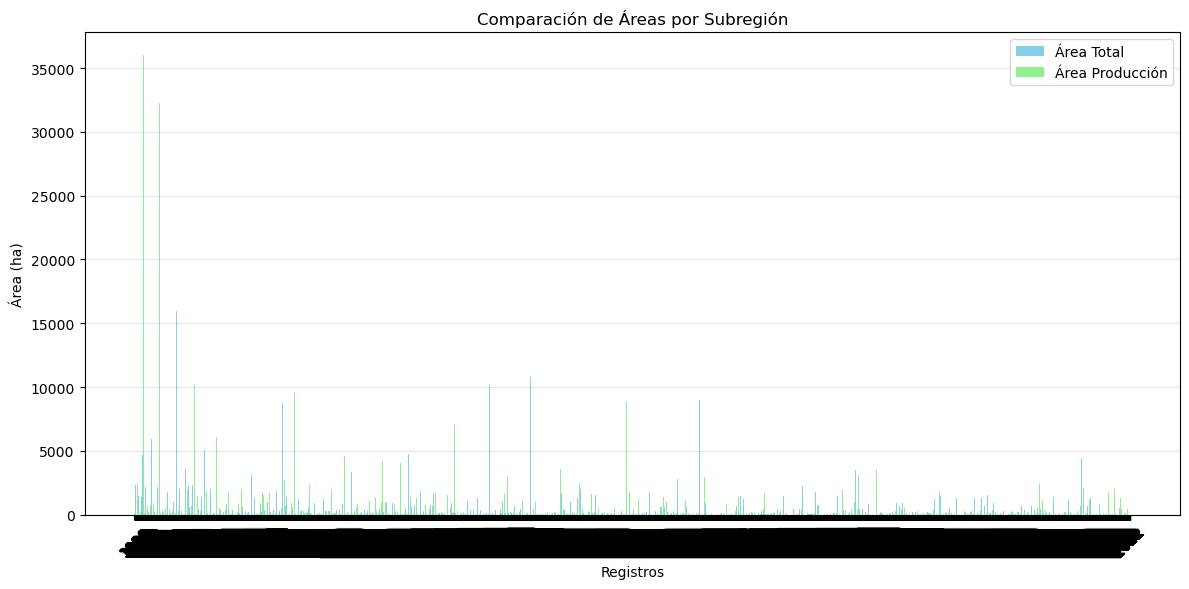

In [83]:
# Filtrar los datos primero
df_filtrado = df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')].copy()

# Asegurarse de usar una columna específica para el eje x (como 'anio' o 'subregion')
plt.figure(figsize=(12, 6))

# Crear posiciones para las barras
indices = range(len(df_filtrado))  # Posiciones numéricas base
ancho_barra = 0.35  # Ancho de cada barra

# Barras para área total
plt.bar(x=[i - ancho_barra/2 for i in indices], 
        height=df_filtrado['area_total'].fillna(0), 
        width=ancho_barra, 
        color='skyblue', 
        label='Área Total')

# Barras para área de producción
plt.bar(x=[i + ancho_barra/2 for i in indices], 
        height=df_filtrado['area_produccion'].fillna(0), 
        width=ancho_barra, 
        color='lightgreen', 
        label='Área Producción')

# Personalización del gráfico
plt.xlabel('Registros')
plt.ylabel('Área (ha)')
plt.title('Comparación de Áreas por Subregión')
plt.legend()

# Si quieres usar los años como etiquetas (asumiendo que existe columna 'anio')
if 'anio' in df_filtrado.columns:
    plt.xticks(indices, df_filtrado['anio'], rotation=45)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
indices = range(len(df_filtrado))
print(len(df_filtrado))
print(indices)

9640
range(0, 9640)


In [87]:
print([i - ancho_barra/2 for i in indices])

[-0.175, 0.825, 1.825, 2.825, 3.825, 4.825, 5.825, 6.825, 7.825, 8.825, 9.825, 10.825, 11.825, 12.825, 13.825, 14.825, 15.825, 16.825, 17.825, 18.825, 19.825, 20.825, 21.825, 22.825, 23.825, 24.825, 25.825, 26.825, 27.825, 28.825, 29.825, 30.825, 31.825, 32.825, 33.825, 34.825, 35.825, 36.825, 37.825, 38.825, 39.825, 40.825, 41.825, 42.825, 43.825, 44.825, 45.825, 46.825, 47.825, 48.825, 49.825, 50.825, 51.825, 52.825, 53.825, 54.825, 55.825, 56.825, 57.825, 58.825, 59.825, 60.825, 61.825, 62.825, 63.825, 64.825, 65.825, 66.825, 67.825, 68.825, 69.825, 70.825, 71.825, 72.825, 73.825, 74.825, 75.825, 76.825, 77.825, 78.825, 79.825, 80.825, 81.825, 82.825, 83.825, 84.825, 85.825, 86.825, 87.825, 88.825, 89.825, 90.825, 91.825, 92.825, 93.825, 94.825, 95.825, 96.825, 97.825, 98.825, 99.825, 100.825, 101.825, 102.825, 103.825, 104.825, 105.825, 106.825, 107.825, 108.825, 109.825, 110.825, 111.825, 112.825, 113.825, 114.825, 115.825, 116.825, 117.825, 118.825, 119.825, 120.825, 121.825, 122

In [89]:
df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')]

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,1,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.000
1,1,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.000
4,1,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.000
8,2,Arroz Tecnificado,Urabá,1990,Mutatá,750.0,355.0,1719.975
11,2,Arroz Tradicional,Urabá,1990,Arboletes,995.0,995.0,1194.000
...,...,...,...,...,...,...,...,...
32709,2,Zanahoria,Oriente,2022,Granada,6.0,6.0,270.000
32711,2,Zanahoria,Oriente,2022,La Unión,362.0,362.0,11228.000
32712,2,Zanahoria,Oriente,2022,Marinilla,190.0,188.0,5640.000
32715,2,Zanahoria,Oriente,2022,Sonsón,75.0,75.0,3525.000


In [236]:
sns.barplot(x='area_produccion', y='area_total', data=df, hue='tipo')

KeyboardInterrupt: 